# 06. Training the served risk model: IEEE-CIS transfer, contract 1.2

The risk score behind `POL-ESC-ML-RISK` comes from a gradient boosting trained on the IEEE-CIS Fraud Detection competition (external, Kaggle), because the bank's own `is_fraud` label carries no learnable signal (notebooks 02 to 04, `reports/ml_full/fraud_risk.md`). This notebook trains that model end to end with the same code the CLI runs (`src.ml.fraud_risk_transfer`), checks that the result reproduces the committed report and bundle, and shows what production serves.

- Data: `data/kaggle/train_transaction.csv` (external, 590,540 rows; never committed) and `data/lakehouse_full.duckdb` (the bank's full history, for the serving window).
- Contract: `src/ml/feature_contract.py` v1.2, 19 deployable features computed from earlier rows of the card only (spec `docs/specs/fraud-risk-model-v1-ieee-cis.md`, sections 4, 10 and 12).
- Decisions: TQ-026 (the transfer and the percentile threshold), TQ-032 (data use approved), TQ-043 (contract 1.2), Kmilo on 5-Oct (the bundle is tracked in git so the Vercel build carries it).

Every number here is offline; nothing is a production gain.

In [1]:
import json, os, time, warnings
from pathlib import Path

os.environ.setdefault("APP_ENV", "test")
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
warnings.filterwarnings("ignore", message=".*IProgress.*")  # a tqdm notice that prints the local path of the kernel
COMPETITION, LAKEHOUSE = Path("data/kaggle"), Path("data/lakehouse_full.duckdb")
COMMITTED_BUNDLE, COMMITTED_REPORT = Path("models/fraud_risk_ieee.joblib"), Path("reports/ml/fraud_risk_transfer.json")
OUT_DIR, OUT_BUNDLE = Path("reports/ml_notebook"), Path("models/fraud_risk_ieee_notebook.joblib")  # both git-ignored
for p in (COMPETITION / "train_transaction.csv", LAKEHOUSE, COMMITTED_BUNDLE, COMMITTED_REPORT):
    assert p.exists(), f"missing {p}"
print("inputs present")

inputs present


## 1. The two sources

The competition fills the canonical frame through `src/ml/ieee_cis_adapter.py`; the bank through `src/ml/bank_adapter.py`. Both are read in a fixed order (timestamp, then id), which is what makes a retrain reproduce the model: 33,932 competition rows share their timestamp with another row.

In [2]:
from src.ml.bank_adapter import load_bank_canonical
from src.ml.feature_contract import CONTRACT_VERSION, DEPLOYABLE_V1, build_contract_features
from src.ml.ieee_cis_adapter import holdout_mask, load_competition

t0 = time.perf_counter()
competition = load_competition(COMPETITION)
bank = load_bank_canonical(LAKEHOUSE)
is_test, days, split_at = holdout_mask(competition["ts"])
print(f"contract v{CONTRACT_VERSION}, {len(DEPLOYABLE_V1)} deployable features")
print(f"competition: {len(competition):,} rows, {int(competition['label'].sum()):,} frauds ({competition['label'].mean() * 100:.2f} %), "
      f"{len(days)} days; holdout from {split_at} ({int(is_test.sum()):,} rows)")
scope = bank[bank["in_scope"]]
print(f"bank: {len(bank):,} rows read for the window and its lookback; {len(scope):,} Web and App charges in the 60 days to {bank.attrs['anchor']}, "
      f"{int(scope['label'].sum())} is_fraud flags")
print(f"loaded in {time.perf_counter() - t0:.0f} s")

contract v1.2, 19 deployable features
competition: 590,540 rows, 20,663 frauds (3.50 %), 182 days; holdout from 2018-04-27 (102,703 rows)
bank: 375,824 rows read for the window and its lookback; 75,366 Web and App charges in the 60 days to 2026-06-17, 73 is_fraud flags
loaded in 6 s


## 2. Train

`train()` is the function the CLI calls. It fits the model on the first 80 % of the competition days, scores the holdout, runs the two ablations, calibrates the threshold on the bank window (percentile 98 of the Web and App scores) and logs the run to MLflow. Here the MLflow store and the outputs go to git-ignored paths, so the committed report stays the one of record.

In [3]:
from src.ml.fraud_risk_transfer import FIT_PARAMS, train

t0 = time.perf_counter()
report = train(COMPETITION, OUT_DIR, OUT_BUNDLE, lakehouse=LAKEHOUSE, tracking_uri="sqlite:///reports/ml_notebook/mlflow.db")
print(f"trained in {time.perf_counter() - t0:.0f} s with {FIT_PARAMS}")
m = report["model"]
print(f"train ROC AUC {m['train']['roc_auc']:.4f}; holdout ROC AUC {m['test']['roc_auc']:.4f}, PR AUC {m['test']['pr_auc']:.4f}")
print(f"threshold {report['threshold']:.4f} ({report['threshold_kind']}), share of the bank window above it {report['bank_calibration']['share_above_threshold']:.3f}")
for name, a in report["ablations"].items():
    print(f"ablation {name}: holdout ROC AUC {a['test']['roc_auc']:.4f}")

trained in 46 s with {'max_iter': 300, 'learning_rate': 0.05, 'max_leaf_nodes': 31, 'min_samples_leaf': 40, 'random_state': 7}
train ROC AUC 0.8579; holdout ROC AUC 0.8157, PR AUC 0.1632
threshold 0.0637 (percentile), share of the bank window above it 0.020
ablation without_card_aggregates: holdout ROC AUC 0.7850
ablation without_discrete_block: holdout ROC AUC 0.7355


## 3. Does it reproduce the committed model?

The report of record is `reports/ml/fraud_risk_transfer.json` and the served bundle is `models/fraud_risk_ieee.joblib`. A retrain has to give the same report (run time, commit and MLflow ids aside) and a bundle that scores every charge the same.

In [4]:
import joblib
import numpy as np

committed = json.loads(COMMITTED_REPORT.read_text(encoding="utf-8"))
mine = json.loads((OUT_DIR / "fraud_risk_transfer.json").read_text(encoding="utf-8"))
for r in (committed, mine):
    for k in ("run_at", "commit", "mlflow"):
        r.pop(k, None)
    r["bank_calibration"].pop("lakehouse", None)
assert committed == mine, "the retrain differs from the committed report"
print("report: identical to the committed one")

served, retrained = joblib.load(COMMITTED_BUNDLE), joblib.load(OUT_BUNDLE)
assert served["features"] == retrained["features"] == DEPLOYABLE_V1 and served["contract_version"] == retrained["contract_version"] == CONTRACT_VERSION
assert abs(served["threshold"] - retrained["threshold"]) < 1e-12
feats = build_contract_features(bank)
X = served["ranker"].transform(feats[feats["in_scope"]][DEPLOYABLE_V1]).to_numpy(float)
s1, s2 = served["model"].predict_proba(X)[:, 1], retrained["model"].predict_proba(X)[:, 1]
print(f"bundle: same features, contract and threshold; max score difference over {len(X):,} bank charges = {np.abs(s1 - s2).max():.2e}")

report: identical to the committed one


bundle: same features, contract and threshold; max score difference over 75,366 bank charges = 0.00e+00


## 4. Observed against predicted, and the bank window

Left: the competition holdout by score decile, mean predicted probability against observed fraud rate. Right: the distribution of the scores on the bank's Web and App window, with the percentile 98 threshold; the 73 `is_fraud` flags of the window are listed by decile below, as a check that the bank label carries no signal.

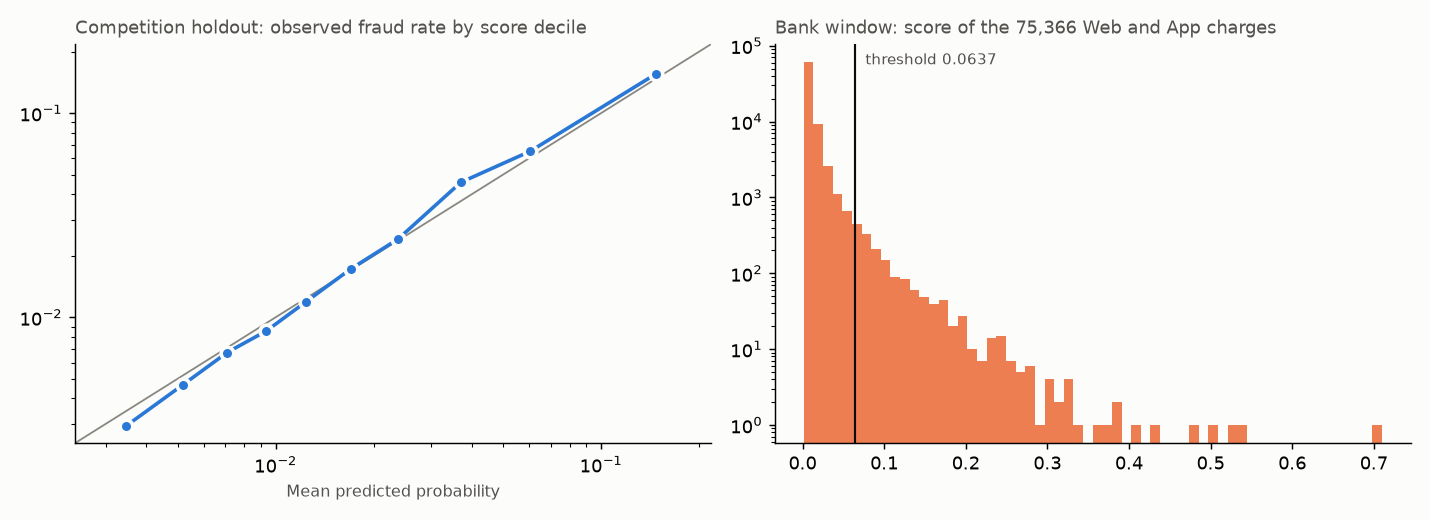

holdout deciles (mean predicted %, observed %): [(0.35, 0.29), (0.52, 0.47), (0.71, 0.67), (0.94, 0.86), (1.24, 1.19), (1.7, 1.72), (2.38, 2.41), (3.7, 4.58), (6.06, 6.5), (14.7, 15.51)]
bank is_fraud flags by score decile: [11, 8, 3, 7, 1, 9, 9, 10, 9, 6]


In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.ml.risk_feature_eda import calibration_table

y = competition["label"].to_numpy(int)
feats_c = build_contract_features(competition)
Xc = served["ranker_competition"].transform(feats_c[DEPLOYABLE_V1]).to_numpy(float)
scores = served["model"].predict_proba(Xc)[:, 1]
test = is_test.to_numpy()
holdout = calibration_table(y[test], scores[test])
bank_bins = calibration_table(scope["label"].to_numpy(int), s1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), dpi=130, facecolor="#fcfcfb")
pred, obs = [b["mean_predicted"] for b in holdout], [max(b["observed_rate"], 1e-3) for b in holdout]
lo, hi = min(pred) * 0.7, max(max(pred), max(obs)) * 1.4
ax1.plot([lo, hi], [lo, hi], color="#898781", linewidth=1)
ax1.plot(pred, obs, color="#2a78d6", linewidth=2, marker="o", markersize=7, markeredgecolor="#fcfcfb", markeredgewidth=2)
ax1.set_xscale("log"); ax1.set_yscale("log"); ax1.set_xlim(lo, hi); ax1.set_ylim(lo, hi)
ax1.set_title("Competition holdout: observed fraud rate by score decile", fontsize=10, loc="left", color="#52514e")
ax1.set_xlabel("Mean predicted probability", fontsize=9, color="#52514e")
ax2.hist(s1, bins=60, color="#eb6834", alpha=0.85)
ax2.axvline(served["threshold"], color="#0b0b0b", linewidth=1.2)
ax2.annotate(f"threshold {served['threshold']:.4f}", xy=(served["threshold"], ax2.get_ylim()[1] * 0.9), xytext=(6, 0), textcoords="offset points", fontsize=8.5, color="#52514e")
ax2.set_yscale("log")
ax2.set_title("Bank window: score of the 75,366 Web and App charges", fontsize=10, loc="left", color="#52514e")
for ax in (ax1, ax2):
    ax.set_facecolor("#fcfcfb")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
fig.savefig("notebooks/22_risk_model_training_calibration.png", facecolor="#fcfcfb")
plt.close(fig)
display(Image(filename="notebooks/22_risk_model_training_calibration.png"))
print("holdout deciles (mean predicted %, observed %):", [(round(b["mean_predicted"] * 100, 2), round(b["observed_rate"] * 100, 2)) for b in holdout])
print("bank is_fraud flags by score decile:", [b["positives"] for b in bank_bins])

## 5. What production serves

`get_orchestrator` (`src/api/dispute_routes.py`) loads the bundle from `FRAUD_MODEL_PATH` (default `models/fraud_risk_ieee.joblib`) when the API starts. The scorer rates only the channels the threshold was calibrated on, returns the score and its three largest contributions, and the policy escalates with `POL-ESC-ML-RISK` when the score passes the bundle's threshold. The bundle is tracked in git since 5-Oct so that the Vercel build, which installs from GitHub, carries it.

In [6]:
from src.ml.transfer_scorer import TransferRiskScorer

scorer = TransferRiskScorer(COMMITTED_BUNDLE)
print(f"features: {len(scorer.features)}; channels scored: {scorer.channels}; policy threshold: {scorer.policy_threshold:.4f}")
# One charge of the window, scored as the orchestrator would: the matched charge plus the card's earlier charges and the customer's profile.
row = scope.sort_values("ts").iloc[-1]
history = bank[(bank["customer_uid"] == row["customer_uid"]) & (bank["ts"] < row["ts"])].sort_values("ts").tail(25)
def as_gateway_row(r):
    return {"transaction_id": r["row_id"], "product_id": r["uid"], "customer_id": r["customer_uid"], "transaction_date": str(r["ts"] + __import__("pandas").Timedelta(hours=6)),
            "amount_usd": float(r["amount_usd"]), "amount": float(r["amount_local"]), "currency": r["currency"], "product_type": r["product_type"],
            "product_currency": r["product_currency"], "transaction_country": r["transaction_country"], "transaction_city": r["transaction_city"], "channel": r["channel"]}
profile = {"country": row["home_country"], "city": row["home_city"]}
score, top = scorer(as_gateway_row(row), [as_gateway_row(h) for _, h in history.iterrows()], profile)
print(f"charge {row['row_id']} ({row['channel']}, {row['amount_usd']:.2f} USD): score {score:.4f}, {'escalates' if score > scorer.policy_threshold else 'does not escalate'}")
for c in top:
    print(f"  {c['phrase']}: value {c['value']:.3f}, contribution {c['contribution']:+.4f}")

features: 19; channels scored: ('Web', 'App'); policy threshold: 0.0637


charge TRX-9TZ7AFGGJCKS37N3B3DP (App, 145.17 USD): score 0.0043, does not escalate
  Amount with cents: value 1.000, contribution -0.0049
  Days since the card's previous charge: value 0.887, contribution -0.0023
  Product is a debit card: value 0.000, contribution +0.0014


## 6. What this notebook does not show

- The model is not validated on bank data: its agreement with `is_fraud` (ROC AUC near 0.5) is reported and never optimized, because that label is random in this dataset.
- The held-out effect of serving it is in `reports/eval_heldout_model.md`: 101 of 107 safe resolutions and 9 of 250 unsafe outcomes, against 105 and 20 without it.
- The feature EDA (min, max, mean and one chart per feature) is `reports/ml/risk_feature_eda.md`.
- Production serves the bundle only from the first deployment that includes it; a merge from Kmilo's account is blocked on Vercel Hobby.